In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR
import matplotlib.pyplot as plt

seed = 42
torch.manual_seed(seed)

D_i, D_k = 10, 40
D_o = 1

num_samples = 200
batch_size = 20
num_epochs = 100
lr = 0.05
momentum = 0.9
step_size = 15
gamma = 0.5

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

true_w = torch.randn(D_i, 1)
true_b = torch.randn(1)
X = torch.randn(num_samples, D_i)
logits_true = X @ true_w + true_b + 0.25 * torch.randn(num_samples, 1)
probs_true = torch.sigmoid(logits_true)
Y = (probs_true > 0.5).float()

dataset = TensorDataset(X, Y)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

model = nn.Sequential(
    nn.Linear(D_i, D_k),
    nn.ReLU(),
    nn.Linear(D_k, D_k),
    nn.ReLU(),
    nn.Linear(D_k, D_o),
).to(device)

def weights_init(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

model.apply(weights_init)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)
scheduler = StepLR(optimizer, step_size=step_size, gamma=gamma)

print(model)

Using device: cpu
Sequential(
  (0): Linear(in_features=10, out_features=40, bias=True)
  (1): ReLU()
  (2): Linear(in_features=40, out_features=40, bias=True)
  (3): ReLU()
  (4): Linear(in_features=40, out_features=1, bias=True)
)
Sequential(
  (0): Linear(in_features=10, out_features=40, bias=True)
  (1): ReLU()
  (2): Linear(in_features=40, out_features=40, bias=True)
  (3): ReLU()
  (4): Linear(in_features=40, out_features=1, bias=True)
)


Epoch   1 | Loss: 0.6809 | Acc: 63.00% | LR: 0.05000
Epoch  10 | Loss: 0.0090 | Acc: 100.00% | LR: 0.05000
Epoch  10 | Loss: 0.0090 | Acc: 100.00% | LR: 0.05000
Epoch  20 | Loss: 0.0030 | Acc: 100.00% | LR: 0.02500
Epoch  20 | Loss: 0.0030 | Acc: 100.00% | LR: 0.02500
Epoch  30 | Loss: 0.0021 | Acc: 100.00% | LR: 0.01250
Epoch  30 | Loss: 0.0021 | Acc: 100.00% | LR: 0.01250
Epoch  40 | Loss: 0.0018 | Acc: 100.00% | LR: 0.01250
Epoch  40 | Loss: 0.0018 | Acc: 100.00% | LR: 0.01250
Epoch  50 | Loss: 0.0016 | Acc: 100.00% | LR: 0.00625
Epoch  50 | Loss: 0.0016 | Acc: 100.00% | LR: 0.00625
Epoch  60 | Loss: 0.0016 | Acc: 100.00% | LR: 0.00313
Epoch  60 | Loss: 0.0016 | Acc: 100.00% | LR: 0.00313
Epoch  70 | Loss: 0.0015 | Acc: 100.00% | LR: 0.00313
Epoch  70 | Loss: 0.0015 | Acc: 100.00% | LR: 0.00313
Epoch  80 | Loss: 0.0015 | Acc: 100.00% | LR: 0.00156
Epoch  80 | Loss: 0.0015 | Acc: 100.00% | LR: 0.00156
Epoch  90 | Loss: 0.0015 | Acc: 100.00% | LR: 0.00078
Epoch  90 | Loss: 0.0015 | Ac

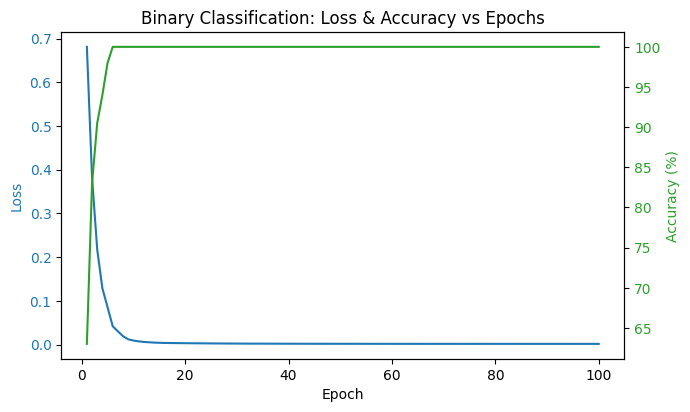

Sample predicted probabilities: [2.3554147521309687e-10, 0.999992847442627, 0.9999998807907104, 4.6598703193012625e-05, 5.108738321268902e-08, 1.0, 5.2148059204171204e-09, 1.0, 2.444941173962434e-07, 4.1264072933699936e-05]


In [ ]:
loss_history = []
acc_history = []

for epoch in range(1, num_epochs + 1):
    model.train()
    epoch_loss = 0.0
    correct = 0
    total = 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * xb.size(0)

        with torch.no_grad():
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            correct += (preds == yb).sum().item()
            total += yb.numel()

    epoch_loss /= total
    acc = correct / total
    loss_history.append(epoch_loss)
    acc_history.append(acc)

    scheduler.step()

    if epoch % 10 == 0 or epoch == 1:
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:3d} | Loss: {epoch_loss:.4f} | Acc: {acc*100:5.2f}% | LR: {current_lr:.5f}')

fig, ax1 = plt.subplots(figsize=(7,4))
color = 'tab:blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color=color)
ax1.plot(range(1, num_epochs+1), loss_history, color=color, label='Loss')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('Accuracy (%)', color=color)
ax2.plot(range(1, num_epochs+1), [a*100 for a in acc_history], color=color, label='Accuracy')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.title('Binary Classification: Loss & Accuracy vs Epochs')
plt.show()

model.eval()
with torch.no_grad():
    sample_logits = model(X[:10].to(device))
    sample_probs = torch.sigmoid(sample_logits).cpu().squeeze()
    print('Sample predicted probabilities:', sample_probs.tolist())